# 火灾烟雾检测
### 火灾事故的频繁发生严重威胁生命财产安全，传统检测手段存在误报率高、响应滞后等局限性，难以满足现代消防安全需求。在此背景下，本项目基于深度学习技术，以 YOLOv5 模型为核心，构建了一套高精度、实时性强的火灾烟雾检测系统。

In [2]:
# 基础库
import os
import sys
import shutil
import random
import time
import math
import yaml
import numpy as np

# PyTorch相关
import torch
import torch.nn as nn
import torch.optim as optim

# 进度条
from tqdm import tqdm

# 图像处理
from PIL import Image, ImageTk

# 可视化
import matplotlib.pyplot as plt

# Tkinter界面
import tkinter as tk
from tkinter import filedialog, messagebox

# OpenCV
import cv2

# YOLOv5相关（确保路径正确）
sys.path.append(r'd:\yolov5_fire_smoke\yolov5')
from train import parse_opt
from models.yolo import Model
from detect import run

# 其他（如有分布式训练等需求）
import threading

### 一、yolov5模型

In [6]:
import sys
sys.path.append(r'd:\yolov5_fire_smoke\yolov5')
from train import parse_opt
from models.yolo import Model
import torch
from types import SimpleNamespace

opt = SimpleNamespace(
    cfg='models/yolov5s.yaml',
    single_cls=False,
    # 其他你需要的参数...
)
model = Model(opt.cfg, ch=3, nc=1 if opt.single_cls else 2, anchors=None)
print(type(model))
print(f"模型参数总数: {sum(p.numel() for p in model.parameters())}")
print("模型加载完成")

Overriding model.yaml nc=80 with nc=2

                 from  n    params  module                                  arguments                     
  0                -1  1      3520  models.common.Conv                      [3, 32, 6, 2, 2]              
  1                -1  1     18560  models.common.Conv                      [32, 64, 3, 2]                
  2                -1  1     18816  models.common.C3                        [64, 64, 1]                   
  3                -1  1     73984  models.common.Conv                      [64, 128, 3, 2]               
  4                -1  2    115712  models.common.C3                        [128, 128, 2]                 
  5                -1  1    295424  models.common.Conv                      [128, 256, 3, 2]              
  6                -1  3    625152  models.common.C3                        [256, 256, 3]                 
  7                -1  1   1180672  models.common.Conv                      [256, 512, 3, 2]             

<class 'models.yolo.DetectionModel'>
模型参数总数: 7025023
模型加载完成


### 二、训练集和数据集的划分

In [ ]:
#训练集和数据集的划分
import os
import shutil

# 原始图片和标签文件夹
img_dir = r'd:\yolov5_fire_smoke\datasets\VOC2020\JPEGImages'
label_dir = r'd:\yolov5_fire_smoke\datasets\VOC2020\labels'

# 目标文件夹
train_img_dir = r'd:\yolov5_fire_smoke\datasets\VOC2020\images\train'
val_img_dir = r'd:\yolov5_fire_smoke\datasets\VOC2020\images\val'
train_label_dir = r'd:\yolov5_fire_smoke\datasets\VOC2020\labels\train'
val_label_dir = r'd:\yolov5_fire_smoke\datasets\VOC2020\labels\val'

# 创建目标文件夹
os.makedirs(train_img_dir, exist_ok=True)
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(train_label_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

# 获取图片列表并排序
imgs = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
imgs.sort()

n = len(imgs)
split_idx = int(n * 0.8)
train_imgs = imgs[:split_idx]
val_imgs = imgs[split_idx:]

# 复制图片和标签
for img in train_imgs:
    shutil.copy(os.path.join(img_dir, img), os.path.join(train_img_dir, img))
    label_name = os.path.splitext(img)[0] + '.txt'
    shutil.copy(os.path.join(label_dir, label_name), os.path.join(train_label_dir, label_name))

for img in val_imgs:
    shutil.copy(os.path.join(img_dir, img), os.path.join(val_img_dir, img))
    label_name = os.path.splitext(img)[0] + '.txt'
    shutil.copy(os.path.join(label_dir, label_name), os.path.join(val_label_dir, label_name))

print(f"train: {len(train_imgs)} images, val: {len(val_imgs)} images")

train: 1647 images, val: 412 images


### 三、Train YOLOv5 model

#### 命令行参数训练

In [ ]:
!python -u train.py --weights "D:\yolov5_fire_smoke\yolov5\weights\yolov5s.pt" --cfg "D:\yolov5_fire_smoke\yolov5\models\yolov5s.yaml" --data "D:\yolov5_fire_smoke\yolov5\data\fire.yaml" --hyp "data/hyps/hyp.scratch-low.yaml" --epochs 30 --batch-size 2 --imgsz 640 --device cpu

#### 使用函数调用来实现训练

In [ ]:
import train

train.run(
    weights=r"D:\\yolov5_fire_smoke\\yolov5\\weights\\yolov5s.pt",
    cfg=r"D:\\yolov5_fire_smoke\\yolov5\\models\\yolov5s.yaml",
    data=r"D:\\yolov5_fire_smoke\\yolov5\\data\\fire.yaml",
    hyp=r"D:\\yolov5_fire_smoke\\yolov5\\data\\hyps\\hyp.scratch-low.yaml",
    epochs=30,
    batch_size=2,
    imgsz=640,
    device='cpu'
)


In [ ]:
import sys
import os
from types import SimpleNamespace
import torch
import yaml
from pathlib import Path

# 将YOLOv5路径加入sys.path，确保能导入train和Callbacks
sys.path.append(r'd:\yolov5_fire_smoke\yolov5')

from train import train
from utils.callbacks import Callbacks

def ensure_opt_attrs(opt, defaults):
    for k, v in defaults.items():
        if not hasattr(opt, k):
            setattr(opt, k, v)

# 1. 加载超参数文件 hyp.yaml
hyp_path = "data/hyps/hyp.scratch-low.yaml"
with open(hyp_path, 'r') as f:
    hyp = yaml.safe_load(f)

# 2. 配置训练参数 opt（不包含 hyp）
opt = SimpleNamespace(
    weights="D:/yolov5_fire_smoke/yolov5/weights/yolov5s.pt",
    cfg="D:/yolov5_fire_smoke/yolov5/models/yolov5s.yaml",
    data="D:/yolov5_fire_smoke/yolov5/data/fire.yaml",
    epochs=50,
    batch_size=2,
    imgsz=640,
    project="runs/train",
    name="exp",
    exist_ok=True,
)

# 3. 必须添加 save_dir，训练代码里会用到
opt.save_dir = str(Path(opt.project) / opt.name)

# 4. 更完善的默认参数，参考YOLOv5官方train.py默认参数
defaults = {
    "weights": opt.weights,      # 方便用已有权重
    "cfg": opt.cfg,
    "data": opt.data,
    "hyp": hyp,                  # 训练超参
    "epochs": opt.epochs,
    "batch_size": opt.batch_size,
    "imgsz": opt.imgsz,
    "save_dir": opt.save_dir,
    "project": opt.project,
    "name": opt.name,
    "exist_ok": opt.exist_ok,

    "device": 'cpu',             # 默认CPU，可自动切换
    "workers": 8,
    "optimizer": 'SGD',
    "sync_bn": False,
    "single_cls": False,
    "rect": False,
    "resume": False,
    "nosave": False,
    "noval": False,
    "noautoanchor": False,
    "evolve": False,
    "bucket": '',
    "image_weights": False,
    "multi_scale": False,
    "freeze": [],
    "close_mosaic": 0,
    "seed": 42,
    "patience": 100,
    "save_period": 10,
    "local_rank": -1,
    "amp": False,
    "verbose": False,
    "noplots": False,
    "val": True,
    "plots": True,
}

ensure_opt_attrs(opt, defaults)

# 5. 设置设备，优先GPU
opt.device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device = torch.device(opt.device)

# 6. 创建回调对象
callbacks = Callbacks()

print("开始训练模型...")

try:
    # 7. 调用train函数，传入 hyp, opt, device, callbacks
    train(hyp, opt, device, callbacks)
    print("训练完成！")
    print(f"模型保存在: {opt.save_dir}")
except Exception as e:
    print(f"训练过程出现错误: {str(e)}")


### 四、评估指标可视化

显示图片: runs/train/exp/results.png


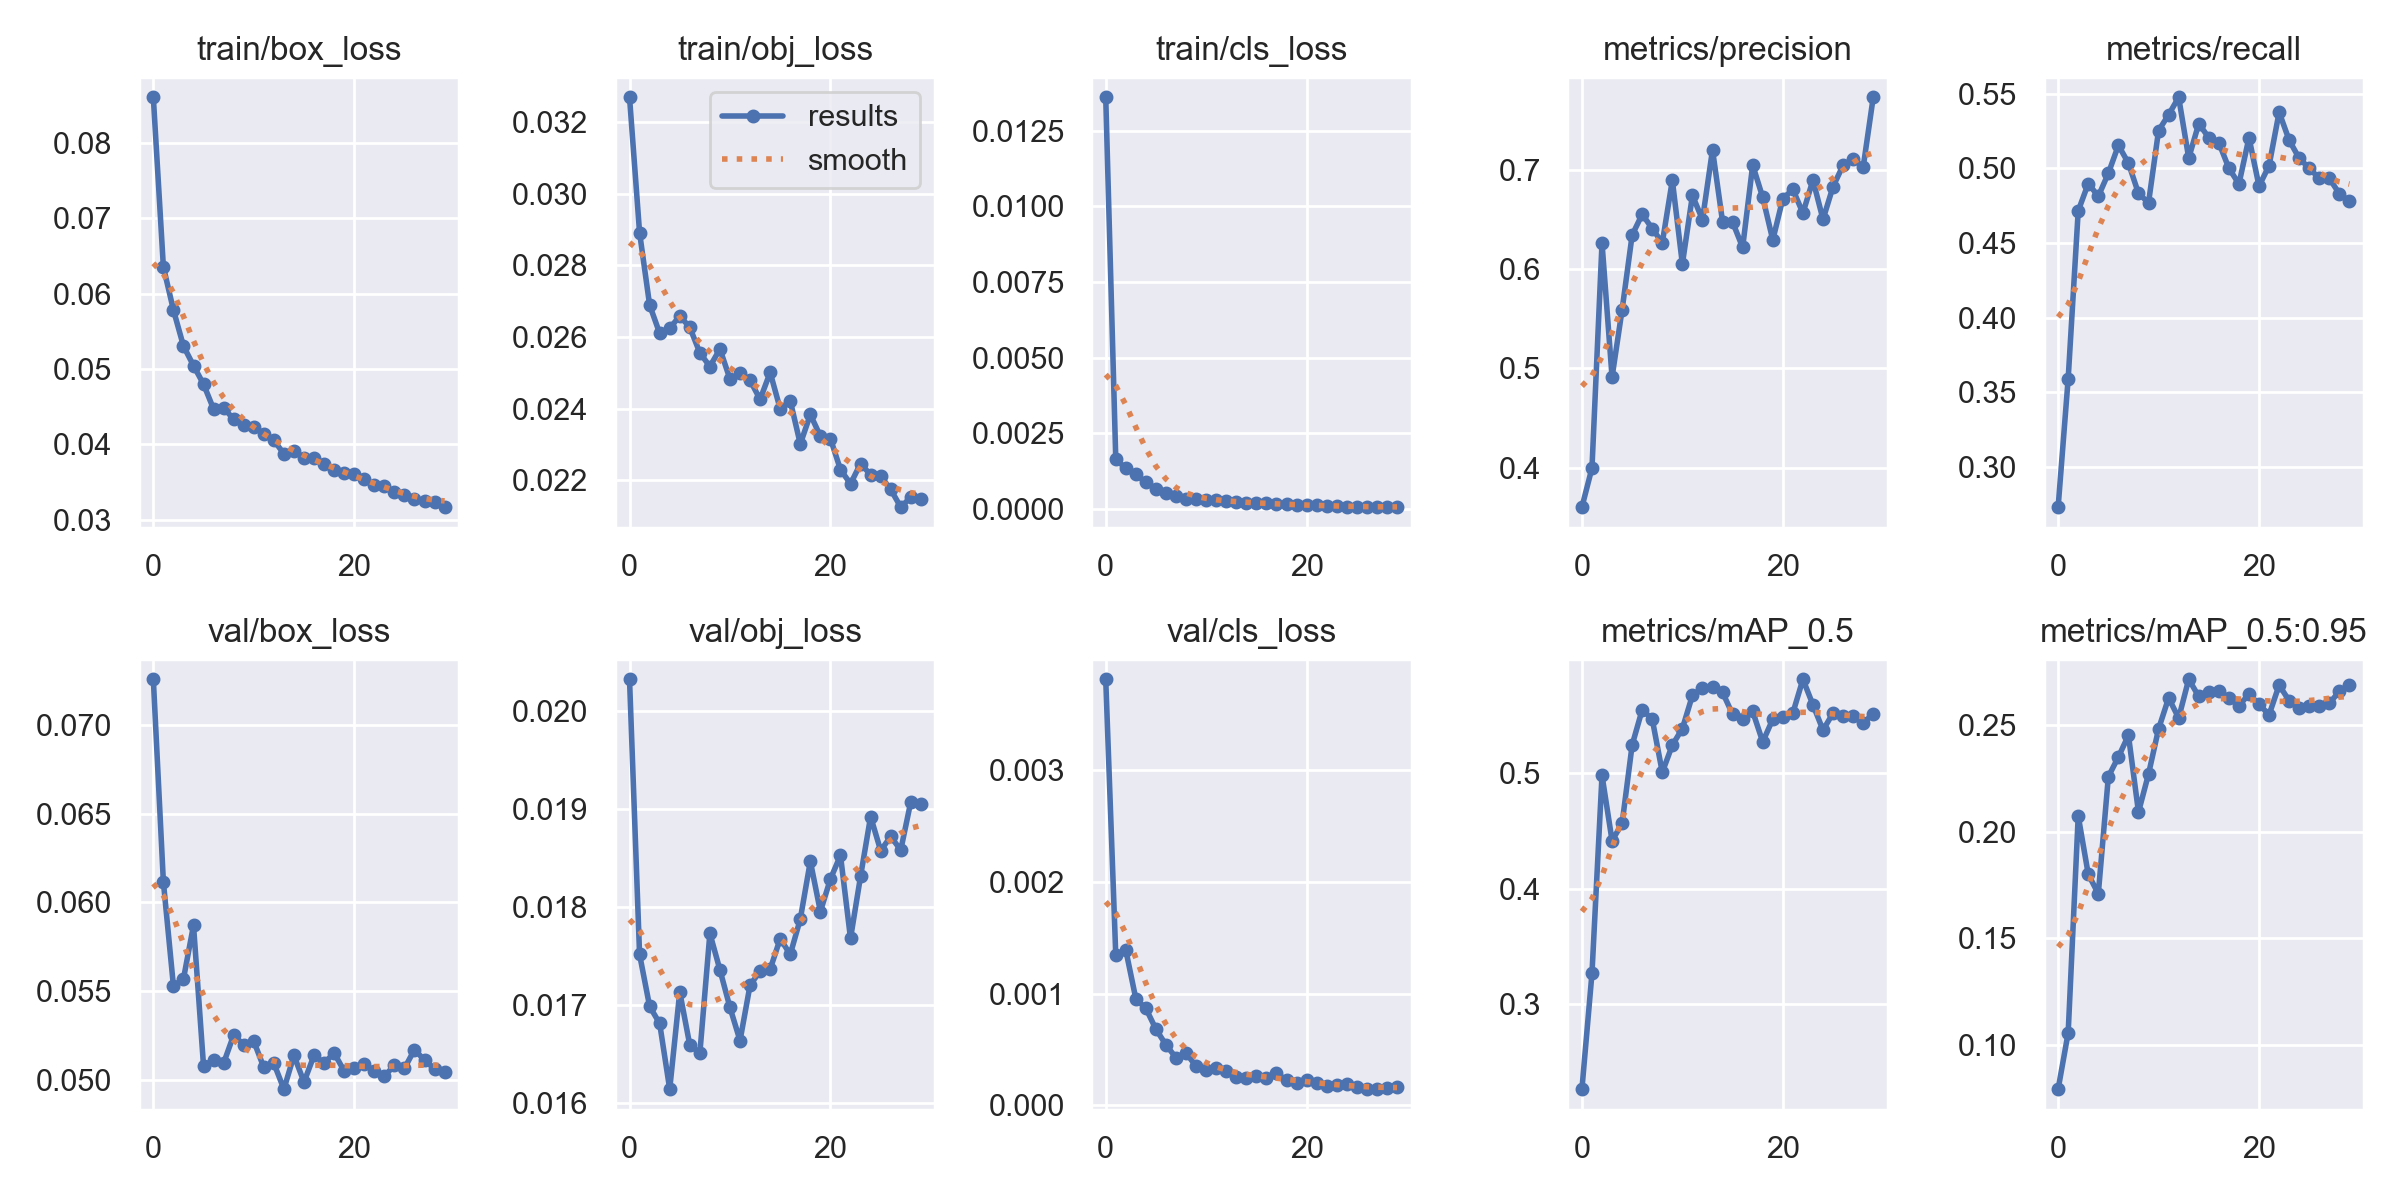

显示图片: runs/train/exp/confusion_matrix.png


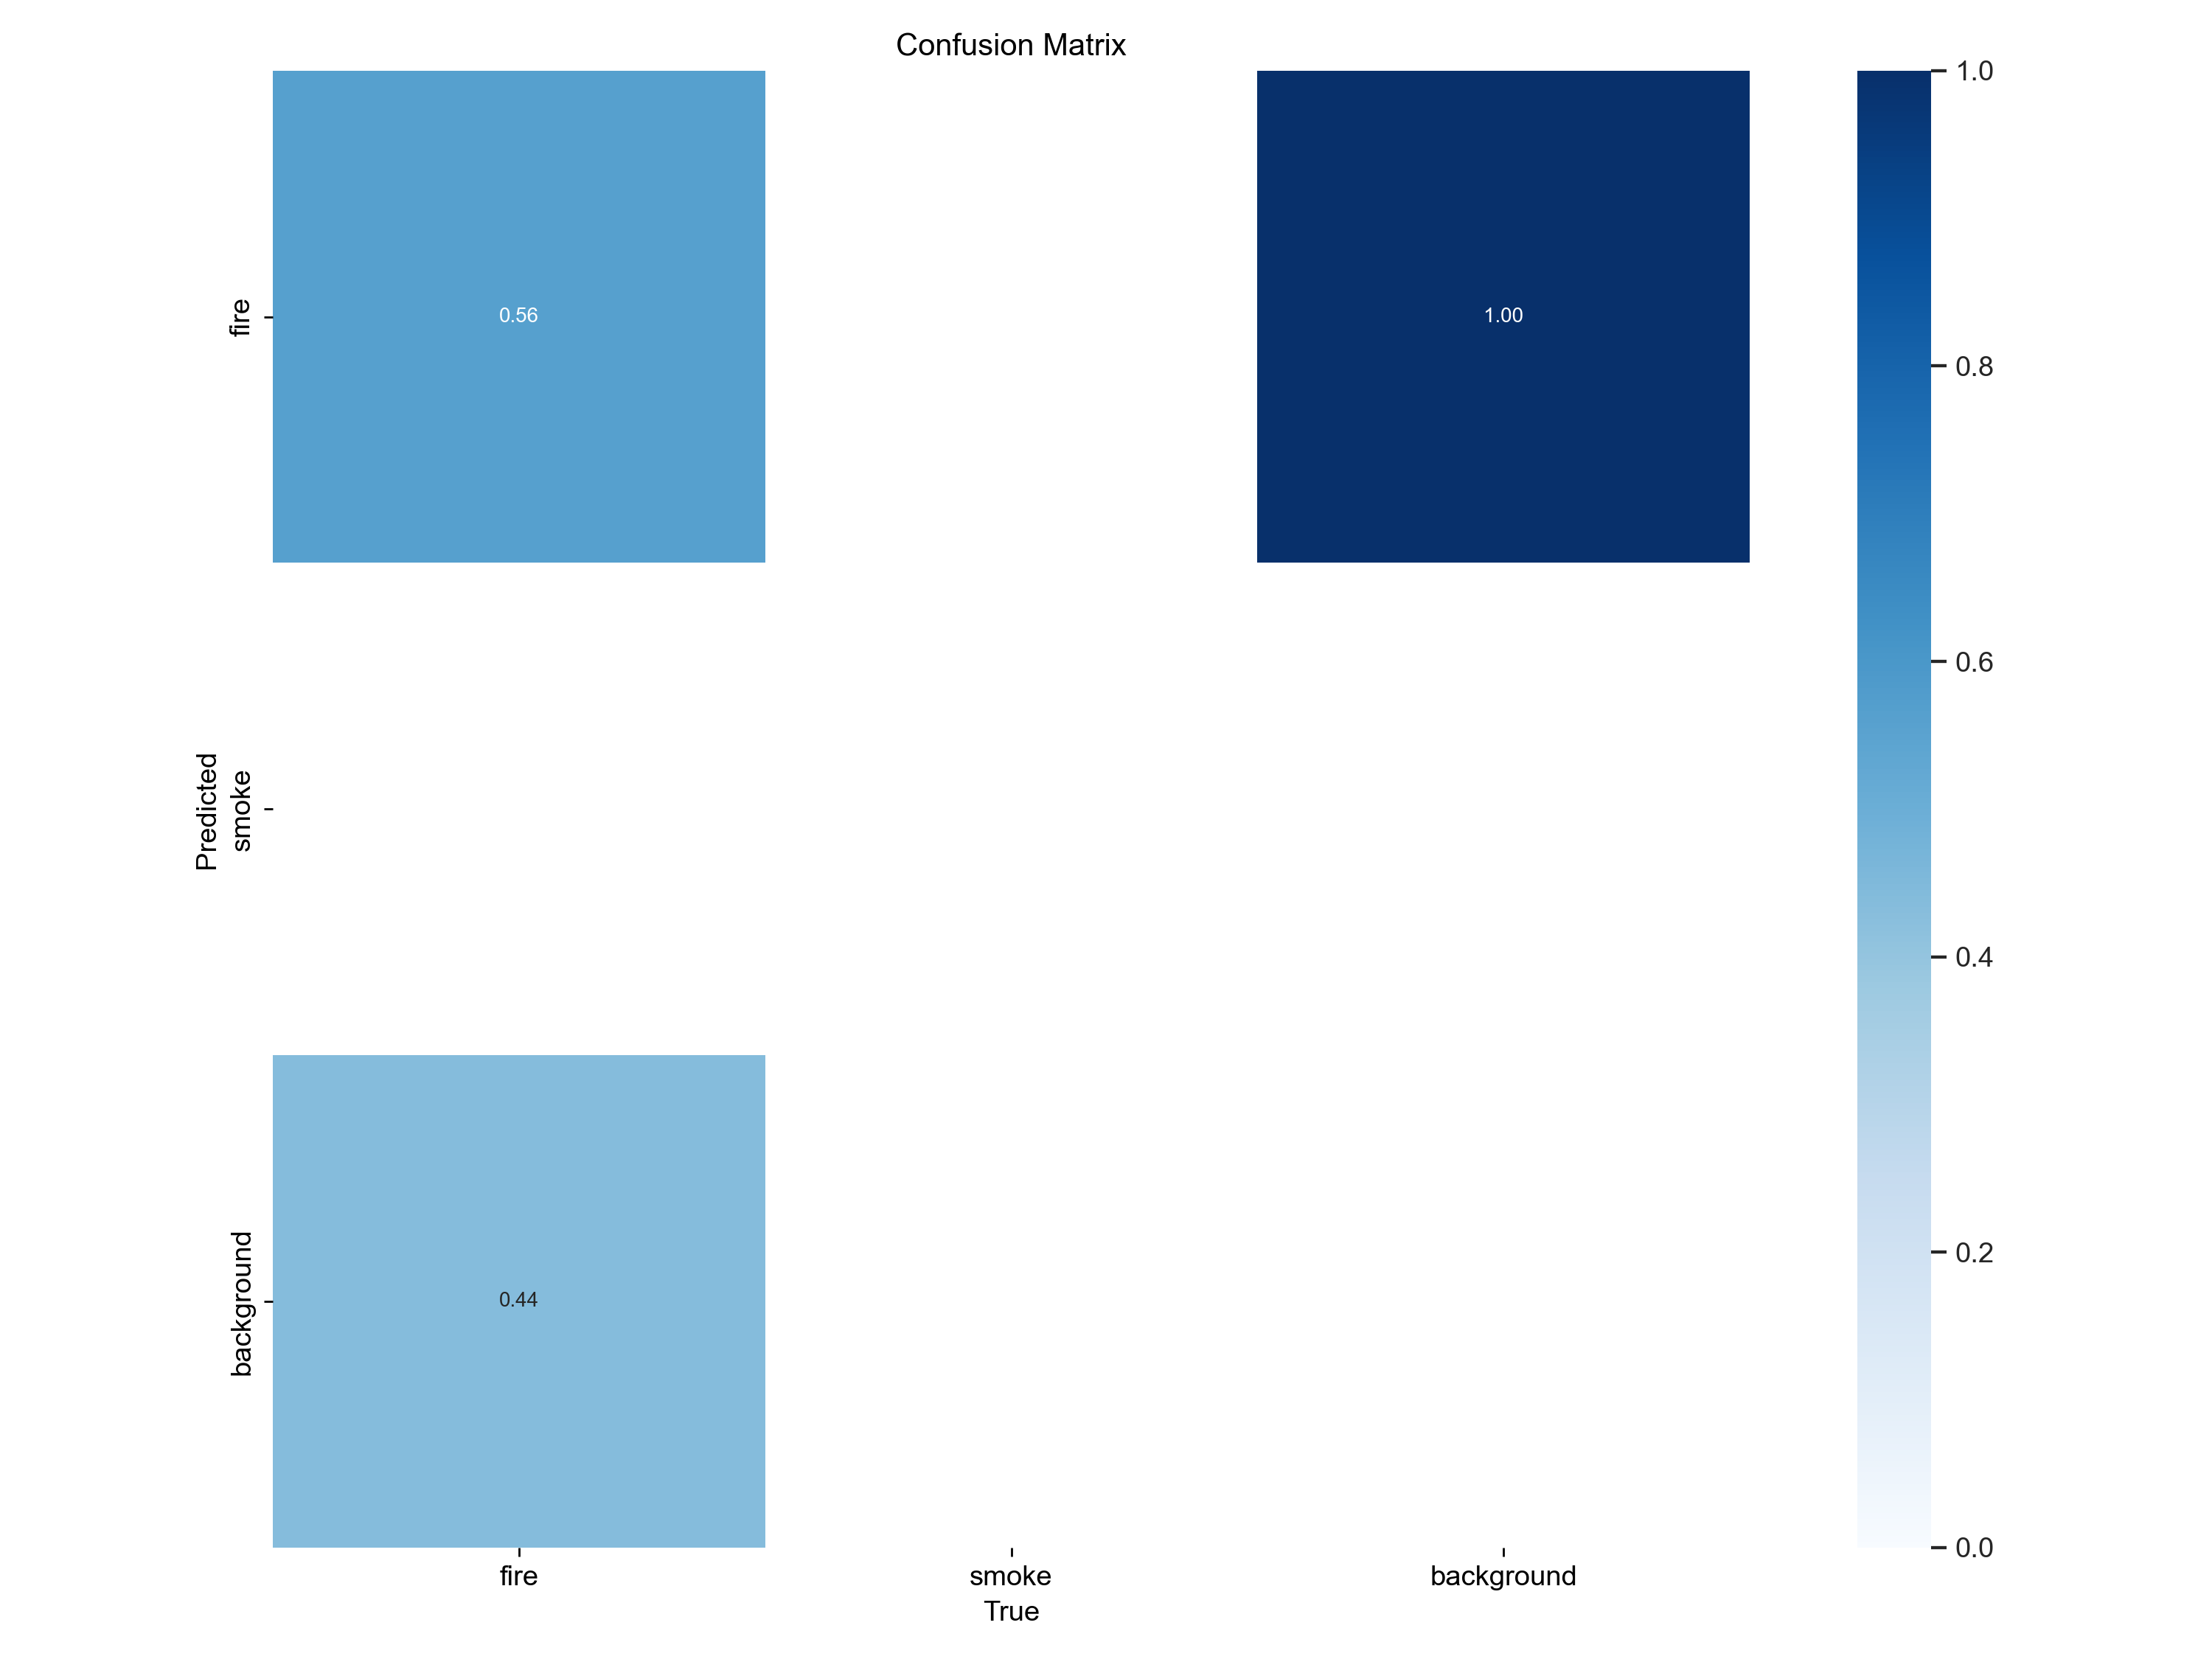

显示图片: runs/train/exp/val_batch0_labels.jpg


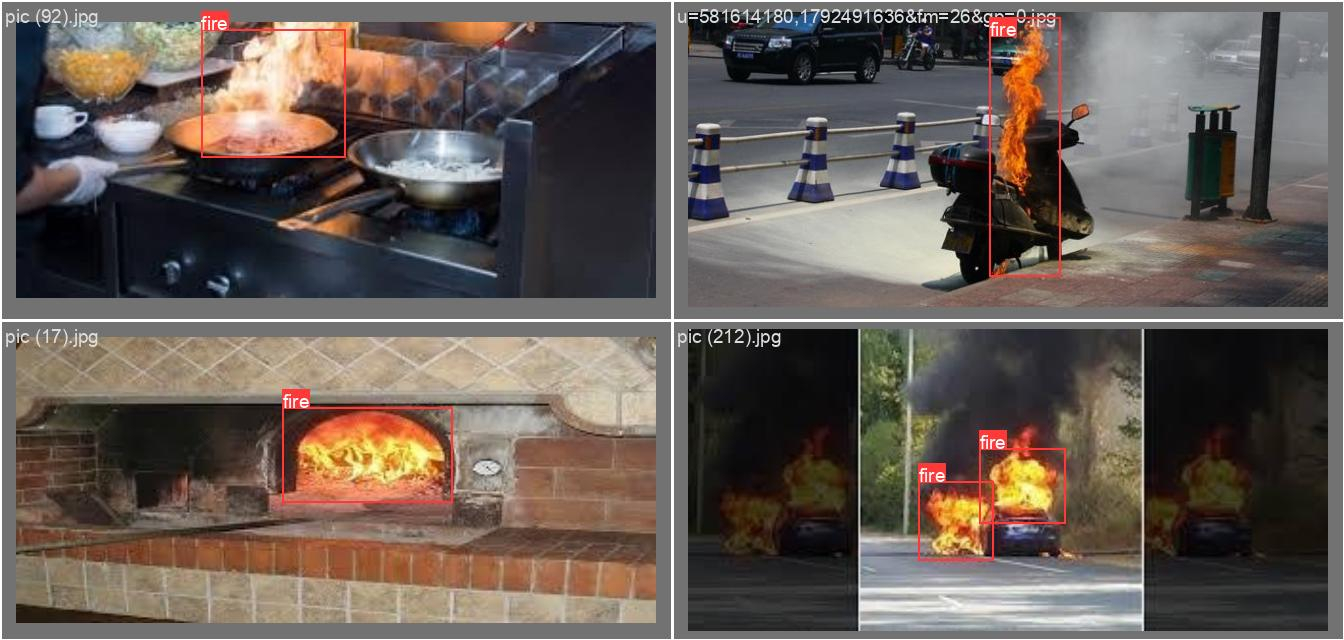

In [ ]:
import sys
sys.path.append(r'd:\yolov5_fire_smoke\yolov5')
from utils.plots import plot_results
from PIL import Image
from IPython.display import display, HTML  # 新增 HTML 用于调整布局
import matplotlib.pyplot as plt

# 生成训练结果图（确保文件存在）
plot_results(file='runs/train/exp/results.csv')

# 定义要显示的图片路径（根据你的实际路径修改）
image_paths = [
    'runs/train/exp/results.png',        # 训练指标曲线
    'runs/train/exp/confusion_matrix.png', # 混淆矩阵
    
    'runs/train/exp/val_batch0_labels.jpg' # 验证集标签示例
]

# 方法1：并排显示所有图片（自动调整布局）
for img_path in image_paths:
    try:
        img = Image.open(img_path)
        print(f"显示图片: {img_path}")  # 打印路径（可选）
        display(img)  # 直接显示图片
    except FileNotFoundError:
        print(f"图片未找到: {img_path}")

### 五、验证集进行测试

In [2]:
#验证模型val
import sys
sys.path.append(r'd:\yolov5_fire_smoke\yolov5')
from val import run

run(
    weights="D:/yolov5_fire_smoke/model/best.pt",
    data="D:\\yolov5_fire_smoke\\yolov5\\data\\fire.yaml",
    imgsz=640,
    batch_size=4,
    device='cpu',
    task='val'
)

YOLOv5  2025-5-12 Python-3.11.5 torch-2.7.0+cpu CPU

Fusing layers... 
YOLOv5s_fs summary: 232 layers, 7249215 parameters, 0 gradients
val: Scanning D:\yolov5_fire_smoke\datasets\VOC2020\labels\val.cache... 412 images, 0 backgrounds, 0 corrupt: 100%|██████████| 412/412 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100%|██████████| 103/103 [23:16<00:00, 13.56s/it]
                   all        412        586      0.864      0.874      0.919       0.46
                  fire        412        586      0.864      0.874      0.919       0.46
Speed: 0.6ms pre-process, 3383.6ms inference, 1.2ms NMS per image at shape (4, 3, 640, 640)
Results saved to runs\val\exp2


((0.8642411435356151,
  0.8737201365187713,
  0.9188625180213736,
  0.46023814651996364,
  0.0,
  0.0,
  0.0),
 array([    0.46024,     0.46024]),
 (0.5693655569576522, 3383.564608189666, 1.1600661046296648))

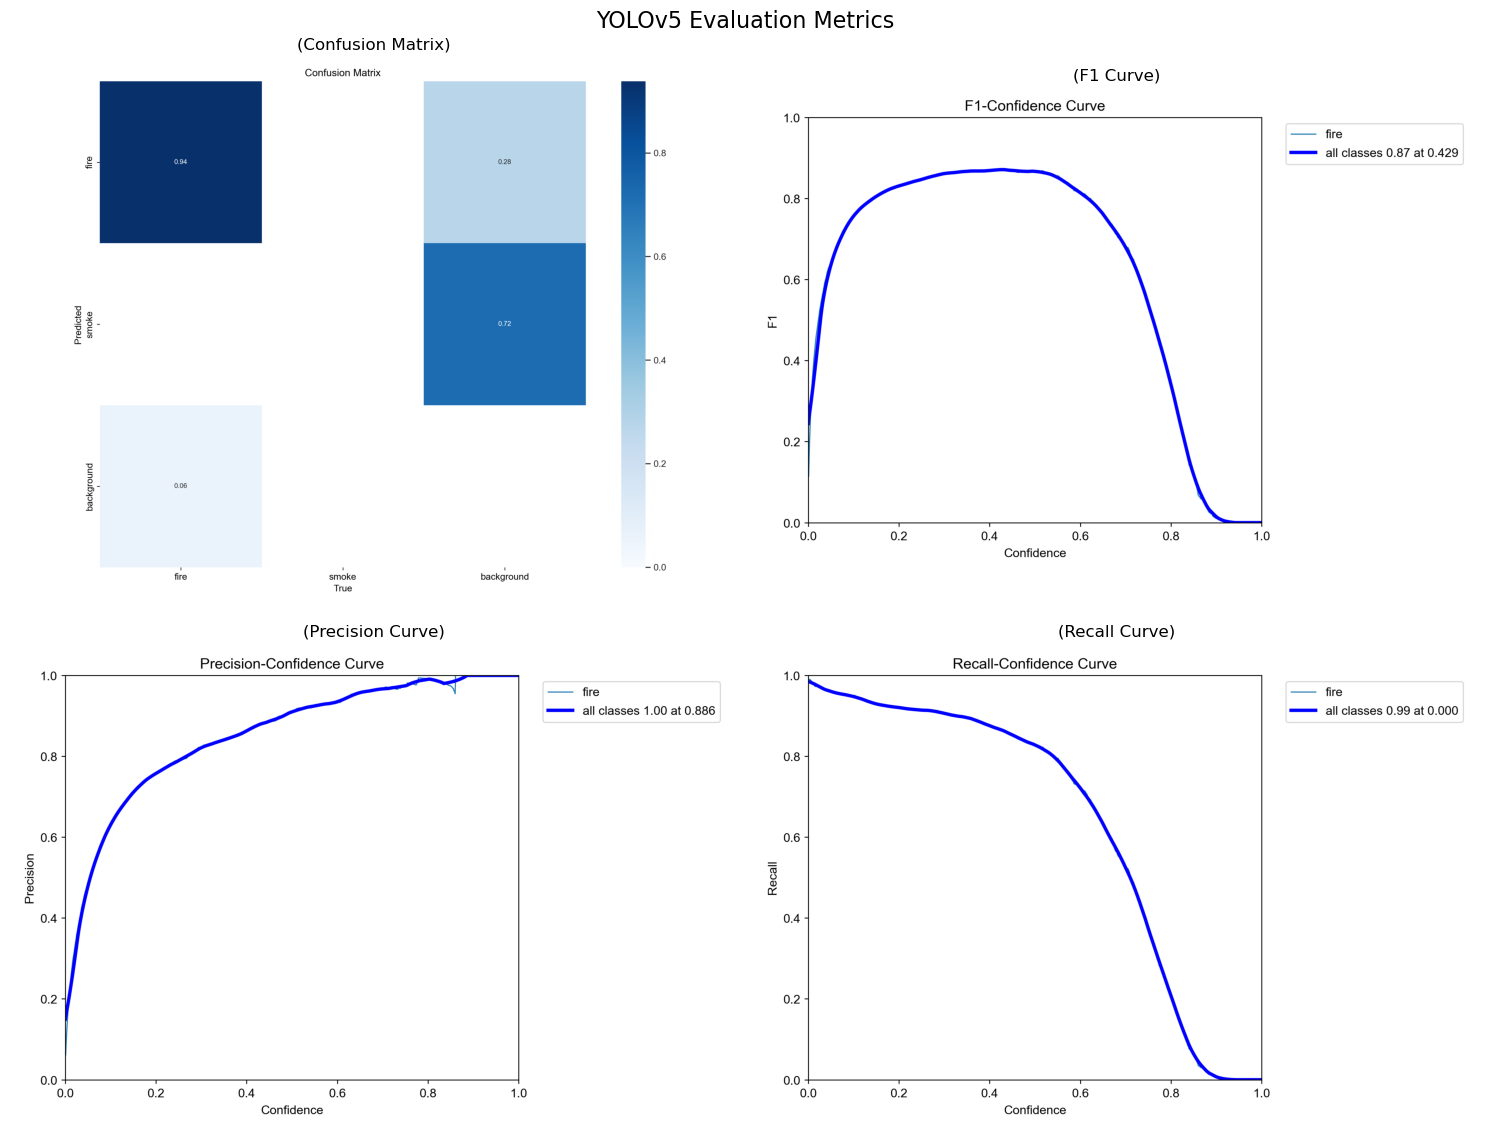

In [5]:
#验证集评估指标
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 设置图片路径（根据你的实际路径修改）
exp_dir = Path('D:\\yolov5_fire_smoke\\yolov5\\runs\\val\\exp')  # 替换为你的实验目录
img_files = [
    exp_dir / 'confusion_matrix.png',
    exp_dir / 'F1_curve.png',
    exp_dir / 'P_curve.png',
    exp_dir / 'R_curve.png'
]

# 确保所有图片存在
assert all([f.exists() for f in img_files]), "Some evaluation images missing"

# 读取所有图片
imgs = [cv2.imread(str(f)) for f in img_files]
imgs = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in imgs]  # BGR转RGB

# 创建2x2的子图布局
fig, axs = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('YOLOv5 Evaluation Metrics', fontsize=16)

# 设置每个子图
titles = ['(Confusion Matrix)', 
          '(F1 Curve)', 
          '(Precision Curve)', 
          '(Recall Curve)']
for idx, (ax, img, title) in enumerate(zip(axs.flat, imgs, titles)):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
output_path = exp_dir / 'val_result.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()


## 五、图形界面——火灾烟雾检测


In [ ]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import threading
import os
import cv2
import time
from detect import run  # 你需要确认 detect.py 已正确配置

class FireSmokeDetectionApp:
    def __init__(self, root):
        self.root = root
        self.root.title("🔥 火焰与烟雾检测系统")
        self.root.geometry("1000x600")
        self.root.configure(bg="white")  # 主窗口白色背景

        self.file_path = tk.StringVar()
        self.confidence_threshold = tk.DoubleVar(value=0.4)
        self.play_speed = tk.DoubleVar(value=1.0)
        self.image = None
        self.running = False

        self.setup_ui()

    def setup_ui(self):
        control_bg = "white"
        fg_color = "black"
        bg_button = "#f0f0f0"
        active_bg = "#d9d9d9"

        control_frame = tk.Frame(self.root, width=320, bg=control_bg)
        control_frame.pack(side=tk.LEFT, fill=tk.Y, padx=5, pady=5)

        font_label = ("Helvetica", 11, "bold")
        font_button = ("Helvetica", 10)

        tk.Label(control_frame, text="📁 文件输入", bg=control_bg, fg=fg_color, font=font_label).pack(pady=(15,8))
        tk.Button(control_frame, text="📷 打开图像", command=self.open_image, bg=bg_button, fg=fg_color, font=font_button, activebackground=active_bg).pack(fill=tk.X, padx=20, pady=4)
        tk.Button(control_frame, text="🎥 打开视频", command=self.open_video, bg=bg_button, fg=fg_color, font=font_button, activebackground=active_bg).pack(fill=tk.X, padx=20, pady=4)
        tk.Button(control_frame, text="📹 打开摄像头", command=self.open_camera, bg=bg_button, fg=fg_color, font=font_button, activebackground=active_bg).pack(fill=tk.X, padx=20, pady=4)
        tk.Entry(control_frame, textvariable=self.file_path, state="readonly", width=30, font=font_button, fg=fg_color, bg=control_bg, readonlybackground=control_bg, relief=tk.FLAT).pack(padx=20, pady=(10,15))

        tk.Label(control_frame, text="🎯 置信度阈值", bg=control_bg, fg=fg_color, font=font_label).pack(pady=(5,8))
        tk.Scale(control_frame, from_=0.1, to=0.9, resolution=0.1,
                 orient=tk.HORIZONTAL, variable=self.confidence_threshold,
                 bg=control_bg, fg=fg_color, troughcolor="#cfcfcf", highlightthickness=0).pack(fill=tk.X, padx=20)

        tk.Label(control_frame, text="⏱️ 播放速度 (0.5x - 2.0x)", bg=control_bg, fg=fg_color, font=font_label).pack(pady=(15,8))
        tk.Scale(control_frame, from_=0.5, to=2.0, resolution=0.1,
                 orient=tk.HORIZONTAL, variable=self.play_speed,
                 bg=control_bg, fg=fg_color, troughcolor="#cfcfcf", highlightthickness=0).pack(fill=tk.X, padx=20)

        tk.Button(control_frame, text="▶️ 开始检测", command=self.start_detection, bg="#4caf50", fg="white", font=font_button, activebackground="#388e3c").pack(fill=tk.X, padx=20, pady=(20,6))
        tk.Button(control_frame, text="⏹️ 停止检测", command=self.stop_detection, bg="#f44336", fg="white", font=font_button, activebackground="#c62828").pack(fill=tk.X, padx=20, pady=6)
        tk.Button(control_frame, text="🧹 清空画布", command=self.clear_canvas, bg="#2196f3", fg="white", font=font_button, activebackground="#1565c0").pack(fill=tk.X, padx=20, pady=6)
        tk.Button(control_frame, text="ℹ️ 关于本项目", command=self.show_about, bg="#607d8b", fg="white", font=font_button, activebackground="#455a64").pack(fill=tk.X, padx=20, pady=(20,10))

        right_frame = tk.Frame(self.root, bg="white")
        right_frame.pack(side=tk.RIGHT, fill=tk.BOTH, expand=True, padx=5, pady=5)

        self.canvas = tk.Canvas(right_frame, bg="white")
        self.canvas.pack(fill=tk.BOTH, expand=True)

        # 删除火焰数量显示标签
        # self.fire_count_label = tk.Label(right_frame, text="识别到火焰数量：0", font=("Helvetica", 14), bg="white", fg="red")
        # self.fire_count_label.pack(pady=8)

    def open_image(self):
        file_path = filedialog.askopenfilename(filetypes=[("Image Files", "*.jpg *.png *.jpeg")])
        if file_path:
            self.file_path.set(file_path)
            self.display_image(file_path)

    def open_video(self):
        file_path = filedialog.askopenfilename(filetypes=[("Video Files", "*.mp4 *.avi *.mov")])
        if file_path:
            self.file_path.set(file_path)

    def open_camera(self):
        self.file_path.set("0")
        self.display_video(0)

    def display_image(self, file_path):
        output_dir = "inference/output"
        os.makedirs(output_dir, exist_ok=True)

        run(
            weights="D:/yolov5_fire_smoke/model/best.pt",
            source=file_path,
            imgsz=(640, 640),
            conf_thres=self.confidence_threshold.get(),
            project=output_dir,
            name="result",
            exist_ok=True
        )

        result_img = os.path.join(output_dir, "result", os.path.basename(file_path))
        if os.path.exists(result_img):
            image = Image.open(result_img)
            image = image.resize((800, 600))
            self.image = ImageTk.PhotoImage(image)
            self.canvas.create_image(0, 0, anchor=tk.NW, image=self.image)
            # 删除更新火焰数量的调用
            # self.update_fire_count(1)
        else:
            messagebox.showerror("错误", "未找到检测结果图片！")

    def display_video(self, file_path):
        self.running = True

        def detect():
            run(
                weights="D:/yolov5_fire_smoke/model/best.pt",
                source=file_path,
                imgsz=(640, 640),
                conf_thres=self.confidence_threshold.get(),
                project="inference/output",
                name="result",
                exist_ok=True
            )

        def play():
            output_video = os.path.join("inference/output/result", os.path.basename(str(file_path)))

            if str(file_path).isdigit():
                cap = cv2.VideoCapture(int(file_path))
            else:
                while not os.path.exists(output_video) and self.running:
                    time.sleep(0.1)
                cap = cv2.VideoCapture(output_video)

            fps = cap.get(cv2.CAP_PROP_FPS)
            if not fps or fps <= 1e-2:
                fps = 25
            base_delay = 1.0 / fps

            while self.running and cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                img = Image.fromarray(frame).resize((800, 600))
                self.image = ImageTk.PhotoImage(img)
                self.canvas.create_image(0, 0, anchor=tk.NW, image=self.image)
                self.canvas.update_idletasks()
                self.canvas.update()

                # 删除火焰数量更新代码
                # self.update_fire_count(3)

                speed = self.play_speed.get()
                delay = base_delay / speed if speed > 0 else base_delay
                time.sleep(delay)

            cap.release()

        threading.Thread(target=detect, daemon=True).start()
        threading.Thread(target=play, daemon=True).start()

    # 删除火焰数量更新函数
    # def update_fire_count(self, count):
    #     def _update():
    #         self.fire_count_label.config(text=f"识别到火焰数量：{count}")
    #     self.fire_count_label.after(0, _update)

    def start_detection(self):
        if not self.file_path.get():
            messagebox.showwarning("警告", "请先选择文件！")
            return

        file = self.file_path.get()
        ext = os.path.splitext(file)[1].lower()

        if file == "0" or file.isdigit():
            self.display_video(int(file))
        elif ext in [".jpg", ".jpeg", ".png"]:
            threading.Thread(target=self.display_image, args=(file,), daemon=True).start()
        elif ext in [".mp4", ".avi", ".mov"]:
            self.display_video(file)
        else:
            messagebox.showerror("错误", "不支持的文件类型！")

    def stop_detection(self):
        self.running = False

    def clear_canvas(self):
        self.canvas.delete("all")
        self.file_path.set("")
        self.image = None
        self.running = False
        # 删除清空火焰数量显示的调用
        # self.update_fire_count(0)

    def show_about(self):
        messagebox.showinfo("关于", 
            "🔥 火焰与烟雾检测系统\n"
            "基于YOLOv5开发\n"
            "版本: 1.0\n"
            "作者: 黄博辉")

if __name__ == "__main__":
    root = tk.Tk()
    app = FireSmokeDetectionApp(root)
    root.mainloop()
